# ВСР 2.2 Классификация цветов Ирисов
----------------
#### Задача
В проекте требуется использовать данные о цветах ирисов для построения модели, которая сможет классифицировать цветок в один из трёх видов (Setosa, Versicolor, Virginica) на основе его характеристик (длина и ширина чашелистиков и лепестков).

Основные шаги:
* Загрузить набор данных о цветах ирисов (Iris dataset).
* Разделить данные на обучающую и тестовую выборки.
* Построить модель классификации с использованием метода ближайших соседей (K-Nearest Neighbors, KNN).
* Оценить точность модели на тестовой выборке.
--------------------------
#### Список идентификаторов
| Имя переменной | Тип переменной    | Смысл                                                 |
|:--------------:|:-----------------:|:-----------------------------------------------------:|
| `df`           | набор данных      | Набор данных "Iris" (150 экземпляров и 5 столбцов)    |
| `X`            | матрица           | Матрица признаков (150x4), содержит числовые данные   |
| `y`            | вектор            | Вектор категорий, содержит названия видов цветков     |
| `species_map`  | словарь           | Словарь для преобразования названий видов в числа     |
| `y_numeric`    | вектор            | Вектор числовых меток видов цветков (0, 1, 2)         |
| `n`            | int               | Количество строк в матрице `X` (150)                  |
| `train_size`   | int               | Размер обучающей выборки (80% от общего числа данных) |
| `shuffle_idx`  | вектор            | Вектор случайных индексов для перемешивания данных    |
| `X_train`      | матрица           | Обучающая выборка признаков (80% от `X`)              |
| `X_test`       | матрица           | Тестовая выборка признаков (20% от `X`)               |
| `y_train`      | вектор            | Обучающая выборка меток классов (80% от `y_numeric`)  |
| `y_test`       | вектор            | Тестовая выборка меток классов (20% от `y_numeric`)   |
| `k`            | int               | Количество ближайших соседей для алгоритма KNN        |
| `y_pred`       | вектор            | Вектор предсказанных классов на тестовой выборке      |
| `accuracy`     | float             | Точность модели KNN на тестовой выборке               |

-----------------
#### Код программы


In [ ]:
# загрузка библиотек
using Pkg
Pkg.add("RDatasets") # для загрузки наборов данных
Pkg.add("Plots") # для создания графиков
Pkg.add("Random") # для генерации случайных чисел (в том числе для перемешивания данных)
Pkg.add("StatsBase") # для вычисления статистик (например, mode)

Точность модели: 93.33333333333333%


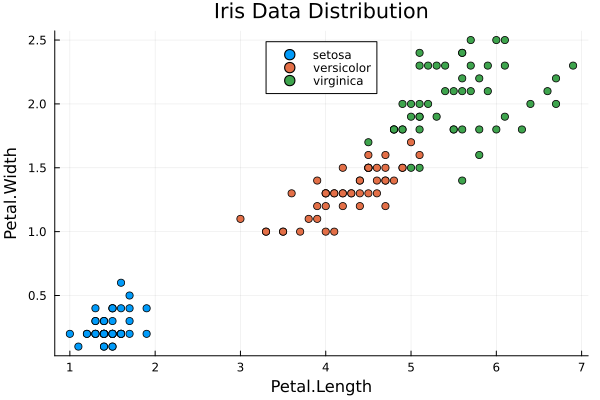

In [1]:
using RDatasets, Plots, Random, StatsBase #подключение библиотек

# Загрузка данных и их реобразование 
df = dataset("datasets", "iris") # Загрузка набора данных "Iris" из библиотеки RDatasets и сохранение его в переменную df
# Извлечение первых четырёх столбцов данных в матрицу X (признаки).
# Извлечение столбца с названиями видов цветка в переменную y.
X, y = Matrix(df[:, 1:4]), df[:, :Species] 
species_map = Dict("setosa" => 0, "versicolor" => 1, "virginica" => 2) # Создание словаря, который отображает назв. видов цветков
y_numeric = [species_map[s] for s in y] # Преобразование строковых меток видов цветка в числовые

# Разделение данных на обучающую и тестовую выборки
Random.seed!(123) # Инициализация генератора случайных чисел
n = size(X, 1) # Вычисление количества строк в матрице X (количество экземпляров данных)
train_size = Int(0.8 * n) # Вычисление размера обучающей выборки (80% от общего числа данных)
shuffle_idx = shuffle(1:n) # Перемешивание индексов данных случайным образом
X_train, X_test = X[shuffle_idx[1:train_size], :], X[shuffle_idx[train_size+1:end], :] # Разделение данных на обучающую и тестовую выборку
y_train, y_test = y_numeric[shuffle_idx[1:train_size]], y_numeric[shuffle_idx[train_size+1:end]] # Разделение меток данных на обучающую и тестовую выборку

# Функция для классификации методом KNN
# Для каждого объекта из тестовой выборки X_test, функция вычисляет расстояние до всех объектов обучающей выборки X_train, сортирует их по возрастанию расстояния и выбирает k ближайших соседей
# Для предсказания класса выбирается наиболее частый класс (mode) среди ближайших соседей
knn_classify(X_train, y_train, X_test, k) = [mode(y_train[sortperm([sum((X_train[j, :] .- x).^2) for j in 1:size(X_train, 1)])[1:k]]) for x in eachrow(X_test)]

# Оценка модели
k = 3 # количество ближайших соседей
y_pred = knn_classify(X_train, y_train, X_test, k) # Применение классификации KNN к тестовой выборке
accuracy = sum(y_pred .== y_test) / length(y_test) # Вычисление точности модели как доли правильно предсказанных классов среди всех тестовых данных
println("Точность модели: ", accuracy * 100, "%")

# Визуализация данных
scatter(X[:, 3], X[:, 4], group=y, legend=:top, xlabel="Petal.Length", ylabel="Petal.Width", title="Iris Data Distribution")